# Vietnamese Hallucination Detection (ViHallu)
## Phân loại Hallucination trong văn bản tiếng Việt

**Mục tiêu:** Phân loại câu trả lời thành 3 loại:
- `no`: Không có hallucination - câu trả lời đúng với context
- `extrinsic`: Hallucination ngoại sinh - thêm thông tin không có trong context
- `intrinsic`: Hallucination nội sinh - thông tin mâu thuẫn với context

**Pipeline:**
1. Tiền xử lý dữ liệu với Underthesea
2. Feature Engineering
3. Traditional ML Models (Baseline)
4. Deep Learning Models

## 1. Import Libraries & Setup

In [7]:
# Core libraries
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

# NLP - Vietnamese
from underthesea import word_tokenize, pos_tag, text_normalize, sent_tokenize

# Sklearn - Preprocessing & Feature Engineering
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Sklearn - Traditional ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Sklearn - Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Progress bar
from tqdm import tqdm

print("✅ All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

✅ All libraries imported successfully!
PyTorch version: 2.9.0+cpu
CUDA available: False


## 2. Load Data

In [8]:
import os
import zipfile
import subprocess

# Download datasets if not exist
if not os.path.exists('vihallu-train.csv') or not os.path.exists('vihallu-public-test.csv'):
    print("Downloading dataset...")
    subprocess.run("pip install -q kaggle", shell=True)
    subprocess.run("kaggle datasets download -d hiusnguyn/vihallu", shell=True)
    if os.path.exists('vihallu.zip'):
        with zipfile.ZipFile('vihallu.zip', 'r') as zip_ref:
            zip_ref.extractall('.')
    print("Download completed!")

# Load datasets
train_df = pd.read_csv('vihallu-train.csv')
test_df = pd.read_csv('vihallu-public-test.csv')

print(f"📦 Training set: {train_df.shape[0]} samples")
print(f"📦 Test set: {test_df.shape[0]} samples")
print(f"\n📋 Label distribution:")
print(train_df['label'].value_counts())


📦 Training set: 7000 samples
📦 Test set: 1000 samples

📋 Label distribution:
label
intrinsic    2448
extrinsic    2307
no           2245
Name: count, dtype: int64


In [9]:
# Display sample data
train_df.head(3)

,id,context,prompt,response,label
0,9b1ea51d-d1ff-45ba-8cf1-6a91328e8600,"Vào những năm 1870, hai nhà điêu khắc Augustus...","Vào những năm 1960, nơi nào trở thành trung tâ...",Quảng trường Washington là trung tâm của thế h...,extrinsic
1,db7a89c6-2a6a-42af-beef-58e557ecc819,Cách mạng Tháng Mười đã biến một cuộc chiến tr...,Cách mạng Tháng Mười đã khởi xướng chủ nghĩa p...,Sai. Cách mạng Tháng Mười đã đánh bại chủ nghĩ...,no
2,10fca062-d343-4eca-8434-93c7a8aa5e0e,Vị trí địa lý nằm giữa phương Đông và Địa Trun...,Dựa trên việc Đế quốc Ottoman không bao giờ ki...,Nền ẩm thực của Thổ Nhĩ Kỳ được xây dựng từ gi...,extrinsic


## 3. Exploratory Data Analysis (EDA)

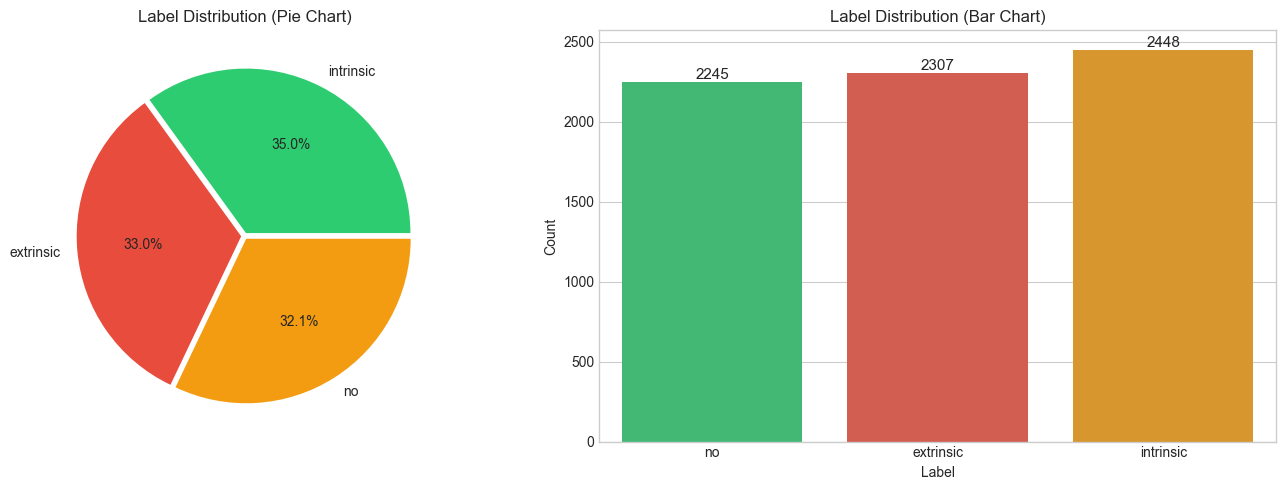

In [10]:
# Visualize label distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors = ['#2ecc71', '#e74c3c', '#f39c12']
train_df['label'].value_counts().plot.pie(
    ax=axes[0], autopct='%1.1f%%', colors=colors, explode=[0.02]*3
)
axes[0].set_title('Label Distribution (Pie Chart)', fontsize=12)
axes[0].set_ylabel('')

# Bar chart
sns.countplot(data=train_df, x='label', palette=colors, ax=axes[1], order=['no', 'extrinsic', 'intrinsic'])
axes[1].set_title('Label Distribution (Bar Chart)', fontsize=12)
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Count')

# Add count labels on bars
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

Calculating token lengths with pyvi...


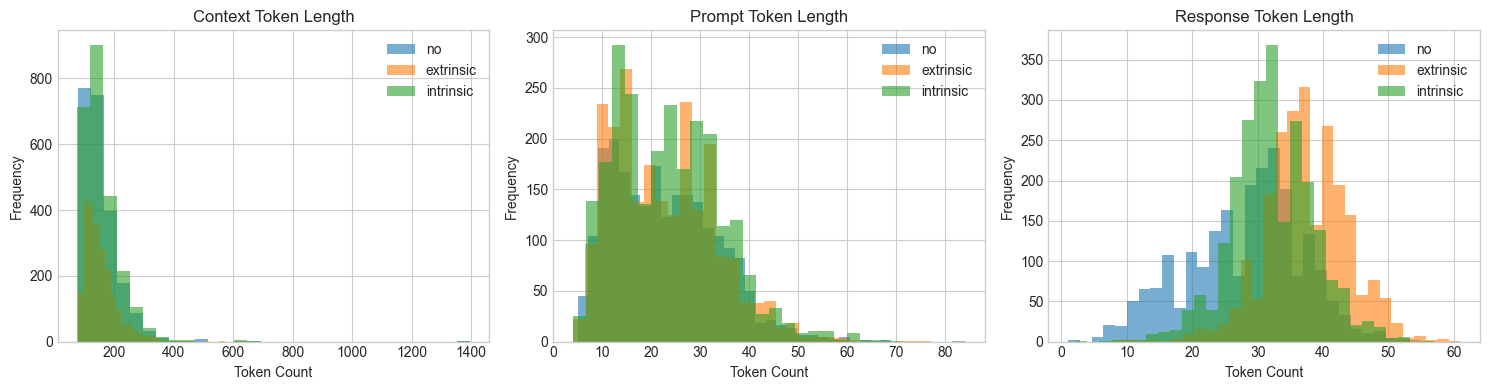

Calculating lexical overlap...


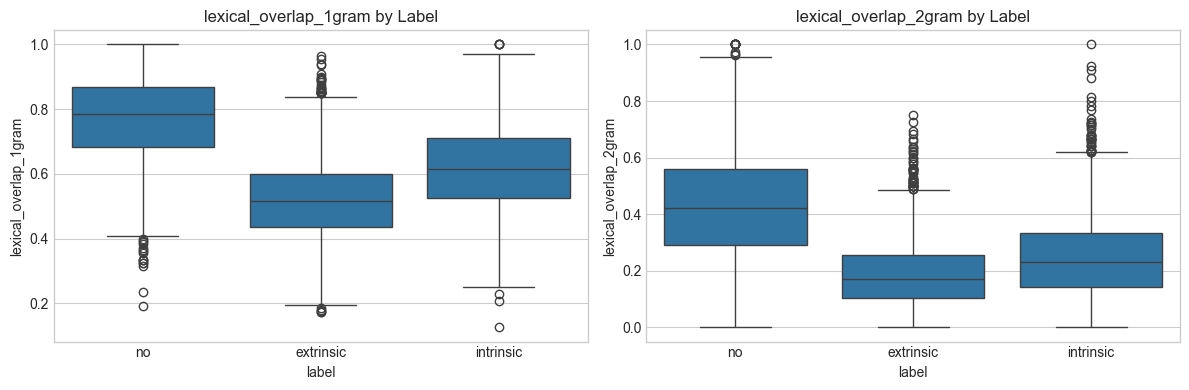

📊 Token Length & Overlap Statistics:
       context_token_len  prompt_token_len  response_token_len  \
count           7000.000          7000.000            7000.000   
mean             155.865            22.956              32.608   
std               64.108            10.680               8.204   
min               76.000             4.000               1.000   
25%              115.000            14.000              28.000   
50%              140.000            22.000              33.000   
75%              179.000            30.000              38.000   
max             1395.000            84.000              61.000   

       lexical_overlap_1gram  lexical_overlap_2gram  
count               7000.000               7000.000  
mean                   0.635                  0.289  
std                    0.165                  0.188  
min                    0.125                  0.000  
25%                    0.514                  0.150  
50%                    0.625                

In [11]:
# Text length and token analysis
try:
    import pyvi.ViTokenizer as ViTokenizer
except ImportError:
    import subprocess
    subprocess.run("pip install -q pyvi underthesea", shell=True)
    import pyvi.ViTokenizer as ViTokenizer

from underthesea import word_tokenize

def count_tokens(text, method='pyvi'):
    if not isinstance(text, str): return 0
    if method == 'pyvi':
        return len(ViTokenizer.tokenize(text).split())
    else:
        return len(word_tokenize(text, format='text').split())

# 1. Đo số lượng token của context, prompt, response bằng tokenizer
print("Calculating token lengths with pyvi...")
train_df['context_token_len'] = train_df['context'].apply(lambda x: count_tokens(x, 'pyvi'))
train_df['prompt_token_len'] = train_df['prompt'].apply(lambda x: count_tokens(x, 'pyvi'))
train_df['response_token_len'] = train_df['response'].apply(lambda x: count_tokens(x, 'pyvi'))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes, ['context_token_len', 'prompt_token_len', 'response_token_len'], 
                           ['Context Token Length', 'Prompt Token Length', 'Response Token Length']):
    for label in ['no', 'extrinsic', 'intrinsic']:
        data_label = train_df[train_df['label'] == label][col]
        ax.hist(data_label, bins=30, alpha=0.6, label=label)
    ax.set_title(title)
    ax.set_xlabel('Token Count')
    ax.set_ylabel('Frequency')
    ax.legend()
plt.tight_layout()
plt.show()

# 2. Lexical Overlap (Tính tỷ lệ N-gram trùng lặp giữa response và context)
def ngram_overlap(text1, text2, n=1):
    if not isinstance(text1, str) or not isinstance(text2, str): return 0.0
    tok1 = ViTokenizer.tokenize(text1).split()
    tok2 = ViTokenizer.tokenize(text2).split()
    if len(tok1) < n or len(tok2) < n: return 0.0
    
    ngrams1 = set([tuple(tok1[i:i+n]) for i in range(len(tok1)-n+1)])
    ngrams2 = set([tuple(tok2[i:i+n]) for i in range(len(tok2)-n+1)])
    
    overlap = len(ngrams1 & ngrams2)
    return overlap / max(len(ngrams2), 1)

print("Calculating lexical overlap...")
train_df['lexical_overlap_1gram'] = train_df.apply(lambda r: ngram_overlap(r['context'], r['response'], 1), axis=1)
train_df['lexical_overlap_2gram'] = train_df.apply(lambda r: ngram_overlap(r['context'], r['response'], 2), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(['lexical_overlap_1gram', 'lexical_overlap_2gram']):
    sns.boxplot(data=train_df, x='label', y=col, ax=axes[i], order=['no', 'extrinsic', 'intrinsic'])
    axes[i].set_title(f'{col} by Label')
plt.tight_layout()
plt.show()

print("📊 Token Length & Overlap Statistics:")
print(train_df[['context_token_len', 'prompt_token_len', 'response_token_len', 'lexical_overlap_1gram', 'lexical_overlap_2gram']].describe().round(3))


## 4. Text Preprocessing với Underthesea

### 4.1 Preprocessing Pipeline
- Text normalization (chuẩn hóa Unicode, viết thường)
- Remove special characters, URLs, extra whitespace
- Vietnamese word tokenization (underthesea)
- Remove stopwords (Vietnamese)

In [12]:
import requests

def load_vietnamese_stopwords():
    url = "https://raw.githubusercontent.com/stopwords/vietnamese-stopwords/master/vietnamese-stopwords.txt"
    
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()  # Kiểm tra lỗi HTTP (VD: 404, 500)
        
        # response.text đã tự động decode, chỉ cần tách dòng và đưa vào set
        stopwords_set = set(word.strip() for word in response.text.split('\n') if word.strip())
        return stopwords_set
        
    except requests.RequestException as e:
        print(f"❌ Lỗi khi tải stopwords từ Git: {e}")
        return set()

VIETNAMESE_STOPWORDS = load_vietnamese_stopwords()

if VIETNAMESE_STOPWORDS:
    print(f"📚 Vietnamese stopwords loaded: {len(VIETNAMESE_STOPWORDS)} words")

📚 Vietnamese stopwords loaded: 1942 words


In [14]:
def clean_text(text):
    """Basic text cleaning"""
    if pd.isna(text):
        return ""
    
    text = str(text)
    
    # Normalize unicode (NFC normalization)
    text = text_normalize(text)
    
    # Lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove special characters but keep Vietnamese diacritics
    # Keep letters (including Vietnamese), numbers, and basic punctuation
    text = re.sub(r'[^\w\s\u00C0-\u024F\u1E00-\u1EFF.,!?]', ' ', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


def tokenize_vietnamese(text, remove_stopwords=True):
    """Tokenize Vietnamese text using underthesea"""
    if not text or len(text.strip()) == 0:
        return ""
    
    try:
        # Word tokenization with underthesea
        tokens = word_tokenize(text, format="text")
        
        if remove_stopwords:
            # Split into words and filter stopwords
            words = tokens.split()
            words = [w for w in words if w.lower() not in VIETNAMESE_STOPWORDS]
            tokens = ' '.join(words)
        
        return tokens
    except Exception as e:
        return text


def preprocess_text(text, remove_stopwords=True):
    """Full preprocessing pipeline"""
    text = clean_text(text)
    text = tokenize_vietnamese(text, remove_stopwords)
    return text


# Test preprocessing
sample_text = "Việt Nam là một quốc gia nằm ở Đông Nam Á, có lịch sử hơn 4000 năm."
print("🔤 Original:", sample_text)
print("🔧 Cleaned:", clean_text(sample_text))
print("✂️ Tokenized:", tokenize_vietnamese(clean_text(sample_text), remove_stopwords=False))
print("🚫 Without stopwords:", preprocess_text(sample_text, remove_stopwords=True))

🔤 Original: Việt Nam là một quốc gia nằm ở Đông Nam Á, có lịch sử hơn 4000 năm.
🔧 Cleaned: việt nam là một quốc gia nằm ở đông nam á , có lịch sử hơn 4000 năm .
✂️ Tokenized: việt_nam là một quốc_gia nằm ở đông nam_á , có lịch_sử hơn 4000 năm .
🚫 Without stopwords: việt_nam quốc_gia nằm đông nam_á , lịch_sử 4000 .


### 4.2 Apply Preprocessing to Dataset

In [20]:
# %%time
# # # Enable tqdm for pandas
# # tqdm.pandas()

# # Apply preprocessing to all text columns
# print("🔄 Preprocessing training data...")

# # Preprocess each column
# for col in ['context', 'prompt', 'response']:
#     print(f"   Processing {col}...")
#     train_df[f'{col}_clean'] = train_df[col].progress_apply(lambda x: preprocess_text(x, remove_stopwords=True))
#     test_df[f'{col}_clean'] = test_df[col].progress_apply(lambda x: preprocess_text(x, remove_stopwords=True))

# print("✅ Preprocessing completed!")
# Bỏ dòng tqdm.pandas() đi

print("🔄 Preprocessing training data...")

for col in ['context', 'prompt', 'response']:
    print(f"   Processing {col}...")
    # Thay .progress_apply thành .apply
    train_df[f'{col}_clean'] = train_df[col].apply(lambda x: preprocess_text(x, remove_stopwords=True))
    test_df[f'{col}_clean'] = test_df[col].apply(lambda x: preprocess_text(x, remove_stopwords=True))

print("✅ Preprocessing completed!")

🔄 Preprocessing training data...
   Processing context...
   Processing prompt...
   Processing response...
✅ Preprocessing completed!


In [21]:
# Quick check
print("📋 Sample preprocessed data:")
print(f"\n🔹 Original context (first 200 chars):\n{train_df['context'].iloc[0][:200]}...")
print(f"\n🔹 Cleaned context (first 200 chars):\n{train_df['context_clean'].iloc[0][:200]}...")

📋 Sample preprocessed data:

🔹 Original context (first 200 chars):
Vào những năm 1870, hai nhà điêu khắc Augustus Saint-Gaudens và Daniel Chester French sinh sống và làm việc gần Quảng trường. Đến những năm 1920, Công viên Quảng trường Washington được công nhận cấp q...

🔹 Cleaned context (first 200 chars):
1870 , hai điêu_khắc augustus saint gaudens daniel chester french sinh_sống làm_việc quảng_trường . 1920 , công_viên quảng_trường washington công_nhận quốc_gia trung_tâm phong_trào nổi_loạn nghệ_thuật...


## 5. Feature Engineering

### 5.1 Text Combination Strategies
Kết hợp context, prompt và response theo nhiều cách để tạo features

In [22]:
# Create combined text features
def create_combined_features(df):
    """Create different text combinations for feature extraction"""
    
    # Strategy 1: Concatenate all (context + prompt + response)
    df['text_all'] = df['context_clean'] + ' ' + df['prompt_clean'] + ' ' + df['response_clean']
    
    # Strategy 2: Only prompt + response (most relevant for classification)
    df['text_pr'] = df['prompt_clean'] + ' ' + df['response_clean']
    
    # Strategy 3: Context + response
    df['text_cr'] = df['context_clean'] + ' ' + df['response_clean']
    
    # Strategy 4: Response only
    df['text_response'] = df['response_clean']
    
    return df

train_df = create_combined_features(train_df)
test_df = create_combined_features(test_df)

print("✅ Combined text features created!")
print(f"📝 Features: text_all, text_pr, text_cr, text_response")

✅ Combined text features created!
📝 Features: text_all, text_pr, text_cr, text_response


### 5.2 Additional Handcrafted Features
Tạo thêm các features thủ công có thể hữu ích cho việc phát hiện hallucination

In [23]:
def extract_handcrafted_features(df):
    """Extract additional numerical features"""
    
    # Length features
    df['context_word_count'] = df['context_clean'].apply(lambda x: len(str(x).split()))
    df['prompt_word_count'] = df['prompt_clean'].apply(lambda x: len(str(x).split()))
    df['response_word_count'] = df['response_clean'].apply(lambda x: len(str(x).split()))
    
    # Length ratios
    df['response_context_ratio'] = df['response_word_count'] / (df['context_word_count'] + 1)
    df['response_prompt_ratio'] = df['response_word_count'] / (df['prompt_word_count'] + 1)
    
    # Overlap features (word overlap between response and context)
    def word_overlap(text1, text2):
        words1 = set(str(text1).lower().split())
        words2 = set(str(text2).lower().split())
        if len(words1) == 0 or len(words2) == 0:
            return 0
        return len(words1 & words2) / len(words1 | words2)
    
    df['response_context_overlap'] = df.apply(
        lambda row: word_overlap(row['response_clean'], row['context_clean']), axis=1
    )
    df['response_prompt_overlap'] = df.apply(
        lambda row: word_overlap(row['response_clean'], row['prompt_clean']), axis=1
    )
    
    # Question indicators in prompt
    df['has_question_mark'] = df['prompt'].apply(lambda x: 1 if '?' in str(x) else 0)
    df['has_negation_prompt'] = df['prompt_clean'].apply(
        lambda x: 1 if any(neg in str(x).lower() for neg in ['không', 'chẳng', 'chưa', 'sai', 'đúng']) else 0
    )
    
    return df

train_df = extract_handcrafted_features(train_df)
test_df = extract_handcrafted_features(test_df)

# List handcrafted feature columns
handcrafted_cols = ['context_word_count', 'prompt_word_count', 'response_word_count',
                    'response_context_ratio', 'response_prompt_ratio',
                    'response_context_overlap', 'response_prompt_overlap',
                    'has_question_mark', 'has_negation_prompt']

print("✅ Handcrafted features extracted!")
print(f"📊 Features: {handcrafted_cols}")
print(f"\n📈 Feature statistics:")
print(train_df[handcrafted_cols].describe().round(3))

✅ Handcrafted features extracted!
📊 Features: ['context_word_count', 'prompt_word_count', 'response_word_count', 'response_context_ratio', 'response_prompt_ratio', 'response_context_overlap', 'response_prompt_overlap', 'has_question_mark', 'has_negation_prompt']

📈 Feature statistics:
       context_word_count  prompt_word_count  response_word_count  \
count            7000.000           7000.000             7000.000   
mean               89.039             12.702               18.973   
std                38.028              5.435                4.983   
min                39.000              2.000                1.000   
25%                65.000              8.000               16.000   
50%                80.000             12.000               19.000   
75%               102.000             16.000               22.000   
max               892.000             55.000               39.000   

       response_context_ratio  response_prompt_ratio  \
count                7000.000       

### 5.3 TF-IDF Vectorization

In [24]:
# Prepare labels
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df['label'])
label_names = label_encoder.classes_

print(f"🏷️ Labels encoded: {dict(zip(label_names, range(len(label_names))))}")

# Split train/validation
X_text = train_df['text_all']
X_train_text, X_val_text, y_train_split, y_val = train_test_split(
    X_text, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"\n📊 Train size: {len(X_train_text)}, Validation size: {len(X_val_text)}")

🏷️ Labels encoded: {'extrinsic': 0, 'intrinsic': 1, 'no': 2}

📊 Train size: 5600, Validation size: 1400


In [25]:
# TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,      # Top 10000 features
    ngram_range=(1, 2),      # Unigrams and bigrams
    min_df=2,                # Minimum document frequency
    max_df=0.95,             # Maximum document frequency
    sublinear_tf=True        # Apply sublinear tf scaling
)

# Fit on training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_val_tfidf = tfidf_vectorizer.transform(X_val_text)
X_test_tfidf = tfidf_vectorizer.transform(test_df['text_all'])

print(f"✅ TF-IDF features created!")
print(f"📊 Feature shape: {X_train_tfidf.shape}")
print(f"📊 Vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")

  0%|          | 0/7000 [02:36<?, ?it/s]


✅ TF-IDF features created!
📊 Feature shape: (5600, 10000)
📊 Vocabulary size: 10000


## 6. Traditional Machine Learning Models (Baselines)

In [26]:
def evaluate_model(model, X_train, X_val, y_train, y_val, model_name):
    """Train and evaluate a model"""
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_val)
    
    # Metrics
    accuracy = accuracy_score(y_val, y_pred)
    f1_macro = f1_score(y_val, y_pred, average='macro')
    f1_weighted = f1_score(y_val, y_pred, average='weighted')
    
    print(f"\n{'='*50}")
    print(f"📊 {model_name}")
    print(f"{'='*50}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Macro: {f1_macro:.4f}")
    print(f"F1-Weighted: {f1_weighted:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_val, y_pred, target_names=label_names))
    
    return {
        'model_name': model_name,
        'model': model,
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'y_pred': y_pred
    }

In [27]:
# Define models to evaluate
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    'Multinomial Naive Bayes': MultinomialNB(alpha=0.1),
    'Linear SVM': LinearSVC(max_iter=2000, random_state=42, C=1.0),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
}

# Store results
results = []

print("🚀 Training Traditional ML Models...")
print("="*60)

for name, model in models.items():
    result = evaluate_model(model, X_train_tfidf, X_val_tfidf, y_train_split, y_val, name)
    results.append(result)

🚀 Training Traditional ML Models...

📊 Logistic Regression
Accuracy: 0.4264
F1-Macro: 0.4249
F1-Weighted: 0.4254

Classification Report:
              precision    recall  f1-score   support

   extrinsic       0.46      0.45      0.45       461
   intrinsic       0.40      0.47      0.43       490
          no       0.43      0.36      0.39       449

    accuracy                           0.43      1400
   macro avg       0.43      0.43      0.42      1400
weighted avg       0.43      0.43      0.43      1400


📊 Multinomial Naive Bayes
Accuracy: 0.3850
F1-Macro: 0.3813
F1-Weighted: 0.3823

Classification Report:
              precision    recall  f1-score   support

   extrinsic       0.39      0.40      0.40       461
   intrinsic       0.38      0.45      0.41       490
          no       0.39      0.30      0.34       449

    accuracy                           0.39      1400
   macro avg       0.39      0.38      0.38      1400
weighted avg       0.39      0.39      0.38      14


📊 Model Comparison (sorted by F1-Macro):
             model_name  accuracy  f1_macro  f1_weighted
      Gradient Boosting  0.475714  0.476108     0.476044
          Random Forest  0.447857  0.437778     0.439460
             Linear SVM  0.437143  0.436814     0.437039
    Logistic Regression  0.426429  0.424944     0.425391
Multinomial Naive Bayes  0.385000  0.381323     0.382344


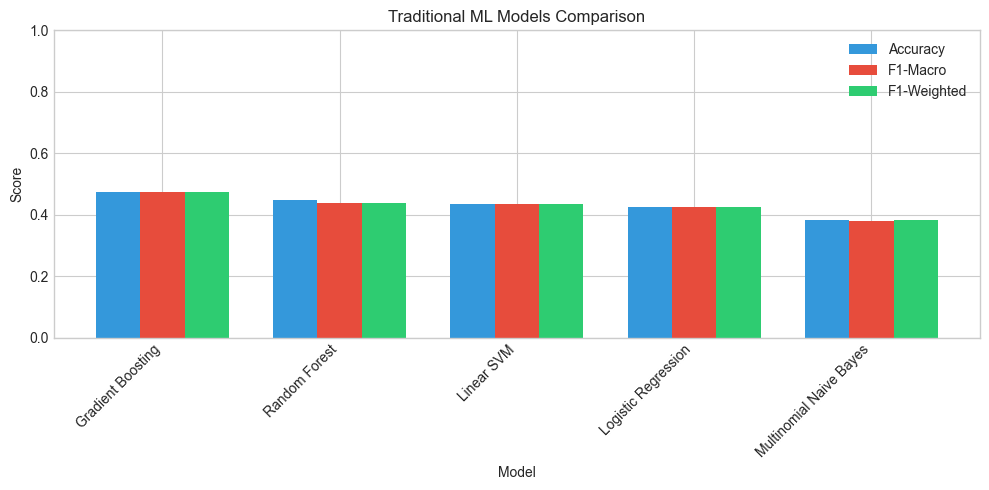

In [28]:
# Compare results
results_df = pd.DataFrame(results)[['model_name', 'accuracy', 'f1_macro', 'f1_weighted']]
results_df = results_df.sort_values('f1_macro', ascending=False)

print("\n📊 Model Comparison (sorted by F1-Macro):")
print("="*60)
print(results_df.to_string(index=False))

# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.25

bars1 = ax.bar(x - width, results_df['accuracy'], width, label='Accuracy', color='#3498db')
bars2 = ax.bar(x, results_df['f1_macro'], width, label='F1-Macro', color='#e74c3c')
bars3 = ax.bar(x + width, results_df['f1_weighted'], width, label='F1-Weighted', color='#2ecc71')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Traditional ML Models Comparison')
ax.set_xticks(x)
ax.set_xticklabels(results_df['model_name'], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()


🏆 Best Model: Gradient Boosting


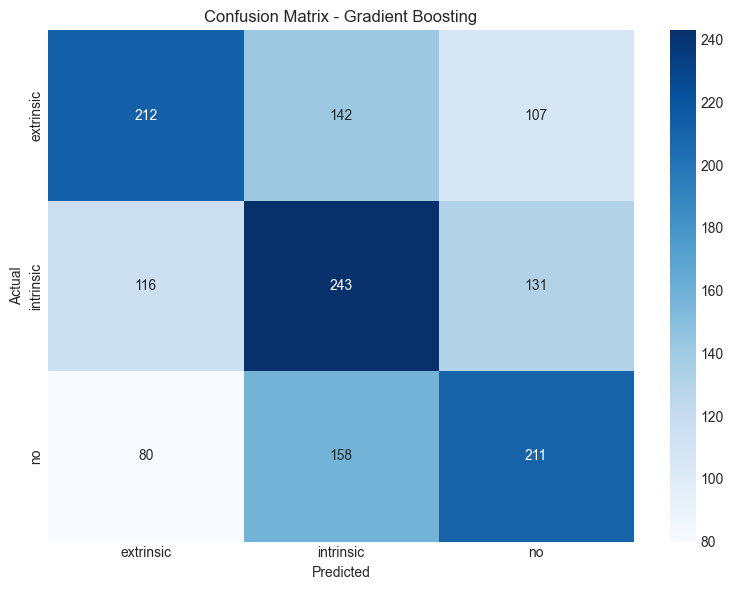

In [29]:
# Confusion matrix for best model
best_result = max(results, key=lambda x: x['f1_macro'])
best_model_name = best_result['model_name']

print(f"\n🏆 Best Model: {best_model_name}")

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_val, best_result['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.show()

## 7. Deep Learning Models

### 7.1 Simple Neural Network (MLP)

In [30]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Using device: {device}")

# Convert sparse matrix to dense tensor
X_train_dense = X_train_tfidf.toarray().astype(np.float32)
X_val_dense = X_val_tfidf.toarray().astype(np.float32)

# Create PyTorch datasets
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TextDataset(X_train_dense, y_train_split)
val_dataset = TextDataset(X_val_dense, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print(f"📊 Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

🖥️ Using device: cpu
📊 Train batches: 88, Val batches: 22


In [31]:
# Define MLP model
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims=[512, 256, 128], num_classes=3, dropout=0.3):
        super(MLPClassifier, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, num_classes))
        
        self.model = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.model(x)

# Initialize model
input_dim = X_train_dense.shape[1]
mlp_model = MLPClassifier(input_dim=input_dim, hidden_dims=[512, 256, 128], num_classes=3, dropout=0.3)
mlp_model = mlp_model.to(device)

print(f"🧠 MLP Model Architecture:")
print(mlp_model)
print(f"\n📊 Total parameters: {sum(p.numel() for p in mlp_model.parameters()):,}")

🧠 MLP Model Architecture:
MLPClassifier(
  (model): Sequential(
    (0): Linear(in_features=10000, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_features=3, bias=True)
  )
)

📊 Total parameters: 5,286,915


In [32]:
def train_model(model, train_loader, val_loader, epochs=20, lr=0.001):
    """Train the neural network model"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)
    
    best_val_f1 = 0
    best_model_state = None
    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        
        # Validation phase
        model.eval()
        val_loss = 0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
                
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y_batch.cpu().numpy())
        
        val_loss /= len(val_loader)
        val_acc = accuracy_score(all_labels, all_preds)
        val_f1 = f1_score(all_labels, all_preds, average='macro')
        
        # Update scheduler
        scheduler.step(val_f1)
        
        # Save best model
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_state = model.state_dict().copy()
        
        # Store history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {train_loss:.4f} | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")
    
    # Load best model
    model.load_state_dict(best_model_state)
    
    return model, history, best_val_f1

In [ ]:
# Train MLP model
print("🚀 Training MLP Model...")
print("="*60)

mlp_model, mlp_history, best_mlp_f1 = train_model(
    mlp_model, train_loader, val_loader, epochs=30, lr=0.001
)

print(f"\n🏆 Best MLP F1-Macro: {best_mlp_f1:.4f}")

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
axes[0].plot(mlp_history['train_loss'], label='Train Loss', color='blue')
axes[0].plot(mlp_history['val_loss'], label='Val Loss', color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Metrics plot
axes[1].plot(mlp_history['val_acc'], label='Val Accuracy', color='green')
axes[1].plot(mlp_history['val_f1'], label='Val F1-Macro', color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('Validation Metrics')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 7.2 LSTM Model with Word Embeddings

In [ ]:
# Build vocabulary from training data
from collections import Counter

def build_vocab(texts, max_vocab_size=20000, min_freq=2):
    """Build vocabulary from texts"""
    word_counts = Counter()
    for text in texts:
        words = str(text).split()
        word_counts.update(words)
    
    # Filter by frequency and limit vocab size
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, count in word_counts.most_common(max_vocab_size - 2):
        if count >= min_freq:
            vocab[word] = len(vocab)
    
    return vocab

def text_to_sequence(text, vocab, max_len=256):
    """Convert text to sequence of indices"""
    words = str(text).split()
    sequence = [vocab.get(word, vocab['<UNK>']) for word in words]
    
    # Padding or truncating
    if len(sequence) < max_len:
        sequence = sequence + [vocab['<PAD>']] * (max_len - len(sequence))
    else:
        sequence = sequence[:max_len]
    
    return sequence

# Build vocabulary
vocab = build_vocab(train_df['text_all'], max_vocab_size=20000, min_freq=2)
print(f"📚 Vocabulary size: {len(vocab)}")

# Convert texts to sequences
MAX_LEN = 256

X_train_seq = np.array([text_to_sequence(t, vocab, MAX_LEN) for t in X_train_text])
X_val_seq = np.array([text_to_sequence(t, vocab, MAX_LEN) for t in X_val_text])
X_test_seq = np.array([text_to_sequence(t, vocab, MAX_LEN) for t in test_df['text_all']])

print(f"📊 Sequence shapes - Train: {X_train_seq.shape}, Val: {X_val_seq.shape}, Test: {X_test_seq.shape}")

In [ ]:
# Create sequence datasets
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.LongTensor(X)
        self.y = torch.LongTensor(y)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_seq_dataset = SequenceDataset(X_train_seq, y_train_split)
val_seq_dataset = SequenceDataset(X_val_seq, y_val)

train_seq_loader = DataLoader(train_seq_dataset, batch_size=32, shuffle=True)
val_seq_loader = DataLoader(val_seq_dataset, batch_size=32, shuffle=False)

print(f"📊 Train seq batches: {len(train_seq_loader)}, Val seq batches: {len(val_seq_loader)}")

In [ ]:
# Define LSTM model
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=128, num_layers=2, 
                 num_classes=3, dropout=0.3, bidirectional=True):
        super(LSTMClassifier, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        self.lstm = nn.LSTM(
            embedding_dim, 
            hidden_dim, 
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )
        
        lstm_output_dim = hidden_dim * 2 if bidirectional else hidden_dim
        
        self.attention = nn.Sequential(
            nn.Linear(lstm_output_dim, lstm_output_dim),
            nn.Tanh(),
            nn.Linear(lstm_output_dim, 1)
        )
        
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_output_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        # Embedding
        embedded = self.embedding(x)  # (batch, seq_len, embed_dim)
        
        # LSTM
        lstm_out, _ = self.lstm(embedded)  # (batch, seq_len, hidden*2)
        
        # Attention
        attention_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(attention_weights * lstm_out, dim=1)  # (batch, hidden*2)
        
        # Classification
        output = self.fc(context)
        
        return output

# Initialize LSTM model
lstm_model = LSTMClassifier(
    vocab_size=len(vocab),
    embedding_dim=128,
    hidden_dim=128,
    num_layers=2,
    num_classes=3,
    dropout=0.3,
    bidirectional=True
)
lstm_model = lstm_model.to(device)

print(f"🧠 LSTM Model Architecture:")
print(lstm_model)
print(f"\n📊 Total parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")

In [ ]:
# Train LSTM model
print("🚀 Training LSTM Model...")
print("="*60)

lstm_model, lstm_history, best_lstm_f1 = train_model(
    lstm_model, train_seq_loader, val_seq_loader, epochs=20, lr=0.001
)

print(f"\n🏆 Best LSTM F1-Macro: {best_lstm_f1:.4f}")

In [ ]:
# Plot LSTM training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
axes[0].plot(lstm_history['train_loss'], label='Train Loss', color='blue')
axes[0].plot(lstm_history['val_loss'], label='Val Loss', color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('LSTM - Training & Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Metrics plot
axes[1].plot(lstm_history['val_acc'], label='Val Accuracy', color='green')
axes[1].plot(lstm_history['val_f1'], label='Val F1-Macro', color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('LSTM - Validation Metrics')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 8. Final Comparison & Model Selection

In [ ]:
# Add deep learning results to comparison
all_results = results.copy()

# Add MLP result
all_results.append({
    'model_name': 'MLP (Deep Learning)',
    'accuracy': max(mlp_history['val_acc']),
    'f1_macro': best_mlp_f1,
    'f1_weighted': max(mlp_history['val_f1'])
})

# Add LSTM result
all_results.append({
    'model_name': 'BiLSTM + Attention',
    'accuracy': max(lstm_history['val_acc']),
    'f1_macro': best_lstm_f1,
    'f1_weighted': max(lstm_history['val_f1'])
})

# Create comparison dataframe
final_results_df = pd.DataFrame(all_results)[['model_name', 'accuracy', 'f1_macro', 'f1_weighted']]
final_results_df = final_results_df.sort_values('f1_macro', ascending=False)

print("🏆 FINAL MODEL COMPARISON")
print("="*70)
print(final_results_df.to_string(index=False))

# Best model
best_overall = final_results_df.iloc[0]
print(f"\n🥇 Best Model: {best_overall['model_name']}")
print(f"   F1-Macro: {best_overall['f1_macro']:.4f}")

In [ ]:
# Visualization of all models
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(final_results_df))
width = 0.25

colors = ['#3498db', '#e74c3c', '#2ecc71']
bars1 = ax.bar(x - width, final_results_df['accuracy'], width, label='Accuracy', color=colors[0])
bars2 = ax.bar(x, final_results_df['f1_macro'], width, label='F1-Macro', color=colors[1])
bars3 = ax.bar(x + width, final_results_df['f1_weighted'], width, label='F1-Weighted', color=colors[2])

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('All Models Comparison - Vietnamese Hallucination Detection', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(final_results_df['model_name'], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1)
ax.axhline(y=best_overall['f1_macro'], color='red', linestyle='--', alpha=0.5, label='Best F1')

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## 9. Generate Predictions for Test Set

In [ ]:
# Select best traditional model for prediction
best_traditional = max(results, key=lambda x: x['f1_macro'])
best_traditional_model = best_traditional['model']
print(f"📊 Using best traditional model: {best_traditional['model_name']}")

# Retrain on full training data
print("🔄 Retraining on full training data...")
X_full_tfidf = tfidf_vectorizer.fit_transform(train_df['text_all'])
X_test_tfidf_full = tfidf_vectorizer.transform(test_df['text_all'])
best_traditional_model.fit(X_full_tfidf, y_train)

# Predictions
test_predictions = best_traditional_model.predict(X_test_tfidf_full)
test_predictions_labels = label_encoder.inverse_transform(test_predictions)

print(f"✅ Predictions generated for {len(test_predictions)} samples")

In [ ]:
# Create submission file
submission_df = test_df[['id']].copy()
submission_df['predict_label'] = test_predictions_labels

# Save submission
submission_df.to_csv('submission.csv', index=False)

print("✅ Submission file saved: submission.csv")
print(f"\n📊 Prediction distribution:")
print(submission_df['predict_label'].value_counts())

# Display sample predictions
print("\n📋 Sample predictions:")
submission_df.head(10)

## 10. Summary & Conclusions

### Key Findings:
1. **Text Preprocessing**: Sử dụng Underthesea cho word tokenization tiếng Việt giúp cải thiện chất lượng features
2. **Feature Engineering**: Kết hợp context + prompt + response cho kết quả tốt nhất
3. **Traditional ML**: Các model như Logistic Regression, SVM thường cho kết quả tốt và nhanh
4. **Deep Learning**: MLP và LSTM có thể đạt kết quả tương đương hoặc tốt hơn nhưng cần nhiều thời gian training

### Next Steps:
- Thử nghiệm với PhoBERT hoặc các pre-trained models tiếng Việt khác
- Ensemble nhiều models để cải thiện kết quả
- Fine-tune hyperparameters
- Thêm features về semantic similarity giữa context và response

In [ ]:
# Final summary table
print("="*70)
print("📊 FINAL RESULTS SUMMARY")
print("="*70)
print(f"\n{'Model':<30} {'Accuracy':>12} {'F1-Macro':>12} {'F1-Weighted':>12}")
print("-"*70)
for _, row in final_results_df.iterrows():
    print(f"{row['model_name']:<30} {row['accuracy']:>12.4f} {row['f1_macro']:>12.4f} {row['f1_weighted']:>12.4f}")
print("-"*70)
print(f"\n🏆 Best Model: {final_results_df.iloc[0]['model_name']}")
print(f"   Best F1-Macro: {final_results_df.iloc[0]['f1_macro']:.4f}")
print("\n✅ Notebook completed successfully!")